# 📘 Deep Learning Text Generation
## Text Generation using Vanilla RNN, LSTM, and GRU

This notebook implements and compares three sequence models:
- **Vanilla RNN** — Baseline; struggles with long-term dependencies
- **LSTM** — Uses input, forget & output gates for long-range memory
- **GRU** — Lightweight gated unit; similar accuracy to LSTM with fewer parameters

**Goal:** Train all three on the same text corpus and compare training loss, text quality, and memory handling.

## 1. 📦 Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. 📥 Load Text Corpus

We use an extended corpus covering multiple topics so the models have enough context to learn grammar, flow, and dependencies. You can replace this with any text (Shakespeare, song lyrics, stories, etc.).

In [2]:
corpus = '''
deep learning is transforming artificial intelligence across many domains
recurrent neural networks are designed for sequential data processing
lstm helps remember long term dependencies in text and time series
gru is faster and simpler than lstm yet achieves similar performance
text generation models predict the next word given previous context
deep learning models can generate meaningful and coherent sentences
natural language processing enables machines to understand human language
neural networks learn patterns by adjusting weights through backpropagation
the vanishing gradient problem makes vanilla rnn struggle with long sequences
gated units in lstm and gru solve the vanishing gradient problem effectively
language models are trained on large corpora to capture grammar and meaning
sequence to sequence models are used in machine translation and summarization
attention mechanisms further improve the ability to capture long range context
deep learning requires large amounts of data and computational power
recurrent models process input one step at a time maintaining a hidden state
'''

print("Corpus loaded.")
print(f"Total characters: {len(corpus)}")
print(f"Lines: {len([l for l in corpus.strip().split(chr(10)) if l.strip()])}")

Corpus loaded.
Total characters: 1101
Lines: 15


## 3. 🔤 Tokenization & Sequence Creation

We convert words to integer tokens, then build **n-gram sequences**:
- For each line, we slide a window to create `[w1]`, `[w1, w2]`, `[w1, w2, w3]` ... as inputs.
- The last token of each sequence is the **label** (next word to predict).
- Sequences are **zero-padded** on the left to uniform length.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1  
print(f"Vocabulary size: {total_words}")


input_sequences = []
for line in corpus.split('\n'):
    line = line.strip()
    if not line:
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

print(f"Total n-gram sequences generated: {len(input_sequences)}")


max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
print(f"Max sequence length (padded): {max_len}")


X = input_sequences[:, :-1]   
y = input_sequences[:, -1]    

print(f"X shape: {X.shape}  → (samples, sequence_length)")
print(f"y shape: {y.shape}  → (samples,)")


print("\n--- Sample sequence (index 5) ---")
sample_tokens = list(X[5])
sample_words  = [tokenizer.index_word.get(t, '<PAD>') if t != 0 else '<PAD>' for t in sample_tokens]
target_word   = tokenizer.index_word.get(y[5], '?')
print("Input tokens :", sample_tokens)
print("Input words  :", sample_words)
print("Target word  :", target_word)

Vocabulary size: 111
Total n-gram sequences generated: 142
Max sequence length (padded): 13
X shape: (142, 12)  → (samples, sequence_length)
y shape: (142,)  → (samples,)

--- Sample sequence (index 5) ---
Input tokens : [np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(5), np.int32(6), np.int32(12), np.int32(29), np.int32(30), np.int32(31)]
Input words  : ['<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', 'deep', 'learning', 'is', 'transforming', 'artificial', 'intelligence']
Target word  : across


## 4. 🧠 Model 1 — Vanilla RNN

### Architecture
```
Embedding(vocab, 64) → SimpleRNN(128) → Dense(vocab, softmax)
```

### Why it struggles
During backpropagation through time (BPTT), gradients are multiplied across many time steps. If the recurrent weight matrix has values < 1, gradients shrink exponentially → **vanishing gradient problem**. SimpleRNN has no gating to control what to keep or discard.

In [4]:
tf.random.set_seed(42)

rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    SimpleRNN(128, return_sequences=False),
    Dense(total_words, activation='softmax')
], name='VanillaRNN')

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

print("\nTraining Vanilla RNN...")
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
final_loss = rnn_history.history['loss'][-1]
final_acc  = rnn_history.history['accuracy'][-1]
print(f"✅ Vanilla RNN done | Final Loss: {final_loss:.4f} | Final Accuracy: {final_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "VanillaRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Vanilla RNN...
✅ Vanilla RNN done | Final Loss: 0.0439 | Final Accuracy: 0.9648


## 5. 🔒 Model 2 — LSTM (Long Short-Term Memory)

### Architecture
```
Embedding(vocab, 64) → LSTM(128) → Dense(vocab, softmax)
```

### How it works
LSTM introduces a **cell state** (long-term memory) controlled by three gates:
- **Forget gate** `f_t = σ(W_f · [h_{t-1}, x_t] + b_f)` — what to erase from cell state
- **Input gate** `i_t = σ(W_i · [h_{t-1}, x_t] + b_i)` — what new info to write
- **Output gate** `o_t = σ(W_o · [h_{t-1}, x_t] + b_o)` — what to expose as hidden state

Cell update: `C_t = f_t ⊙ C_{t-1} + i_t ⊙ tanh(W_C · [h_{t-1}, x_t])`

In [5]:
tf.random.set_seed(42)

lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    LSTM(128, return_sequences=False),
    Dense(total_words, activation='softmax')
], name='LSTM')

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

print("\nTraining LSTM...")
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
final_loss = lstm_history.history['loss'][-1]
final_acc  = lstm_history.history['accuracy'][-1]
print(f"✅ LSTM done | Final Loss: {final_loss:.4f} | Final Accuracy: {final_acc:.4f}")

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
✅ LSTM done | Final Loss: 0.1080 | Final Accuracy: 0.9648


## 6. ⚡ Model 3 — GRU (Gated Recurrent Unit)

### Architecture
```
Embedding(vocab, 64) → GRU(128) → Dense(vocab, softmax)
```

### How it differs from LSTM
GRU **merges** the cell state and hidden state, using only **two gates**:
- **Reset gate** `r_t = σ(W_r · [h_{t-1}, x_t])` — how much past to forget
- **Update gate** `z_t = σ(W_z · [h_{t-1}, x_t])` — how much of new state to accept

Hidden state: `h_t = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ tanh(W · [r_t ⊙ h_{t-1}, x_t])`

Fewer parameters → **faster training**, often similar accuracy to LSTM.

In [6]:
tf.random.set_seed(42)

gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    GRU(128, return_sequences=False),
    Dense(total_words, activation='softmax')
], name='GRU')

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

print("\nTraining GRU...")
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
final_loss = gru_history.history['loss'][-1]
final_acc  = gru_history.history['accuracy'][-1]
print(f"✅ GRU done | Final Loss: {final_loss:.4f} | Final Accuracy: {final_acc:.4f}")

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training GRU...
✅ GRU done | Final Loss: 0.0449 | Final Accuracy: 0.9648


## 7. 📉 Training Loss Comparison

Plot the loss curves for all three models. Gated architectures (LSTM, GRU) typically converge faster and reach lower loss than Vanilla RNN.

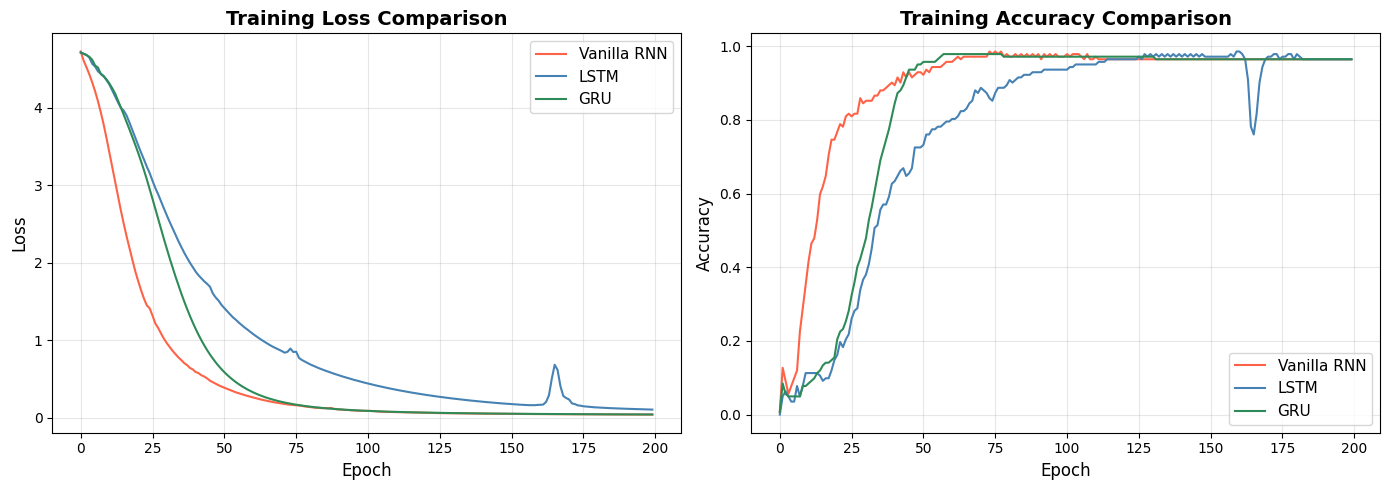

Chart saved as 'loss_accuracy_comparison.png'


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(rnn_history.history['loss'],  label='Vanilla RNN', color='tomato',    linewidth=1.5)
axes[0].plot(lstm_history.history['loss'], label='LSTM',        color='steelblue', linewidth=1.5)
axes[0].plot(gru_history.history['loss'],  label='GRU',         color='seagreen',  linewidth=1.5)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss",  fontsize=12)
axes[0].set_title("Training Loss Comparison", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# --- Accuracy ---
axes[1].plot(rnn_history.history['accuracy'],  label='Vanilla RNN', color='tomato',    linewidth=1.5)
axes[1].plot(lstm_history.history['accuracy'], label='LSTM',        color='steelblue', linewidth=1.5)
axes[1].plot(gru_history.history['accuracy'],  label='GRU',         color='seagreen',  linewidth=1.5)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Training Accuracy Comparison", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'loss_accuracy_comparison.png'")

## 8. 📊 Final Metrics Summary Table

In [8]:
models_info = {
    'Model'         : ['Vanilla RNN', 'LSTM', 'GRU'],
    'Final Loss'    : [
        round(rnn_history.history['loss'][-1], 4),
        round(lstm_history.history['loss'][-1], 4),
        round(gru_history.history['loss'][-1], 4)
    ],
    'Final Accuracy': [
        round(rnn_history.history['accuracy'][-1], 4),
        round(lstm_history.history['accuracy'][-1], 4),
        round(gru_history.history['accuracy'][-1], 4)
    ],
    'Parameters'    : [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
}

print(f"{'Model':<15} {'Final Loss':>12} {'Accuracy':>12} {'Parameters':>12}")
print("-" * 55)
for i in range(3):
    print(f"{models_info['Model'][i]:<15} "
          f"{models_info['Final Loss'][i]:>12.4f} "
          f"{models_info['Final Accuracy'][i]:>12.4f} "
          f"{models_info['Parameters'][i]:>12,}")

Model             Final Loss     Accuracy   Parameters
-------------------------------------------------------
Vanilla RNN           0.0439       0.9648       46,127
LSTM                  0.1080       0.9648      120,239
GRU                   0.0449       0.9648       95,919


## 9. ✍️ Text Generation Function

The function works as follows:
1. Tokenize the seed text into integer indices
2. Pad the sequence to `max_len - 1`
3. Run the model → take the **argmax** of the softmax output (most probable next word)
4. Append that word to the seed and repeat for `next_words` steps

In [9]:
def generate_text(model, seed_text, next_words=8, temperature=1.0):
    """
    Generate text by predicting one word at a time.

    Args:
        model       : trained Keras model
        seed_text   : starting string
        next_words  : number of words to generate
        temperature : > 1 = more random, < 1 = more deterministic
    """
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')

        # Get probability distribution over vocabulary
        predictions = model.predict(token_list, verbose=0)[0].astype('float64')

        # Apply temperature scaling
        predictions = np.log(predictions + 1e-10) / temperature
        predictions = np.exp(predictions)
        predictions = predictions / predictions.sum()

        # Greedy (temperature=1.0 with argmax for deterministic output)
        predicted_index = np.argmax(predictions)

        # Map index back to word
        output_word = tokenizer.index_word.get(predicted_index, '')
        result += ' ' + output_word

    return result

print("Text generation function defined.")

Text generation function defined.


## 10. 🧪 Generate and Compare Text Samples

In [10]:
seed_phrases = [
    "deep learning",
    "recurrent neural",
    "lstm helps",
    "gru is"
]

print("=" * 70)
print("GENERATED TEXT COMPARISON (8 words predicted per seed)")
print("=" * 70)

for seed in seed_phrases:
    print(f"\n🌱 Seed: '{seed}'")
    print(f"  RNN : {generate_text(rnn_model,  seed, next_words=8)}")
    print(f"  LSTM: {generate_text(lstm_model, seed, next_words=8)}")
    print(f"  GRU : {generate_text(gru_model,  seed, next_words=8)}")

print("\n" + "=" * 70)

GENERATED TEXT COMPARISON (8 words predicted per seed)

🌱 Seed: 'deep learning'
  RNN : deep learning requires large amounts of data and computational power
  LSTM: deep learning models can generate meaningful and coherent sentences power
  GRU : deep learning is transforming artificial intelligence across many domains domains

🌱 Seed: 'recurrent neural'
  RNN : recurrent neural networks are designed for sequential data processing time
  LSTM: recurrent neural networks are designed for sequential data processing processing
  GRU : recurrent neural networks are designed for sequential data processing processing

🌱 Seed: 'lstm helps'
  RNN : lstm helps remember long term dependencies in text and time
  LSTM: lstm helps remember long term dependencies in text and time
  GRU : lstm helps remember long term dependencies in text and time

🌱 Seed: 'gru is'
  RNN : gru is faster and simpler than lstm yet achieves similar
  LSTM: gru is faster and simpler than lstm yet achieves similar
  GRU : 

## 11. 🔬 Architecture Comparison — Parameter Count vs Gates

| Feature | Vanilla RNN | LSTM | GRU |
|---|---|---|---|
| Gates | None | 3 (input, forget, output) | 2 (reset, update) |
| Cell State | No | Yes | No (merged into h) |
| Vanishing Gradient | Severe | Mitigated | Mitigated |
| Long-Term Memory | Poor | Excellent | Good |
| Training Speed | Fastest | Slowest | Moderate |
| Parameters | Fewest | Most | Moderate |
| Best Use Case | Very short sequences | Long, complex text | Balanced performance |

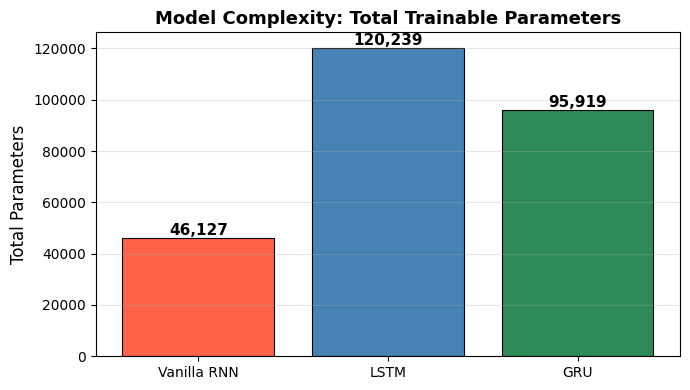

In [11]:
# Visualize parameter count comparison
model_names  = ['Vanilla RNN', 'LSTM', 'GRU']
param_counts = [rnn_model.count_params(), lstm_model.count_params(), gru_model.count_params()]
colors       = ['tomato', 'steelblue', 'seagreen']

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, param_counts, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, param_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylabel('Total Parameters', fontsize=12)
plt.title('Model Complexity: Total Trainable Parameters', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('parameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. ✅ Conclusion

### Key Observations

**Vanilla RNN**
- Learns short, local patterns quickly
- Suffers from **vanishing gradients** on longer sequences
- Generated text may repeat or lose coherence after a few words
- Fewest parameters → fastest per epoch

**LSTM**
- Gating mechanisms allow it to **selectively remember and forget** information
- Captures long-range dependencies better (e.g., subject-verb agreement across many words)
- Higher parameter count due to 4 weight matrices per unit
- Generally achieves the lowest training loss on text tasks

**GRU**
- Combines forget and input gates into a single **update gate**
- Fewer parameters than LSTM → faster training with comparable performance
- Good balance of speed and accuracy; often preferred in production

### When to Use Which?

| Situation | Recommendation |
|---|---|
| Very short sequences (< 10 tokens) | SimpleRNN is sufficient |
| Long documents, complex grammar | LSTM |
| Fast prototyping, resource-limited | GRU |
| Production NLP pipelines | Transformer-based models (BERT, GPT) |

## 🎓 Student Extension Tasks

Try these modifications to deepen your understanding:

1. **Stacked layers**: Add a second RNN/LSTM/GRU layer with `return_sequences=True`
2. **Dropout regularization**: Add `Dropout(0.2)` after the recurrent layer to reduce overfitting
3. **Larger corpus**: Replace the corpus with a Shakespeare excerpt or song lyrics
4. **Bigger embedding**: Change `64` → `128` in the Embedding layer
5. **Bidirectional LSTM**: Wrap LSTM with `tf.keras.layers.Bidirectional` for better context
6. **Temperature sampling**: Modify `generate_text` to sample from the distribution instead of taking argmax for more creative outputs
7. **Top-k sampling**: Only sample from the top-k most probable words for coherent diversity